In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar


Error: cannot read response file srctoolout_720_RMF_00001.fits
Error: cannot read response file srctoolout_720_RMF_00001.fits
/tmp/ipykernel_57950/1260269547.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



 response file  read skipped
Energy range: **-0.3,,9.0-**
Plot command list is now empty

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80_DECEMBER/srctoolout_720_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.378e+00 +/- 1.970e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM7  Channel Type: PI
  Exposure Time: 3.551e+05 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

 response file  read skipped

2 spectra  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_720_SourceSpec_00001.fits  Spectrum 2
Net count rate (cts/s) for Spectrum:2  1

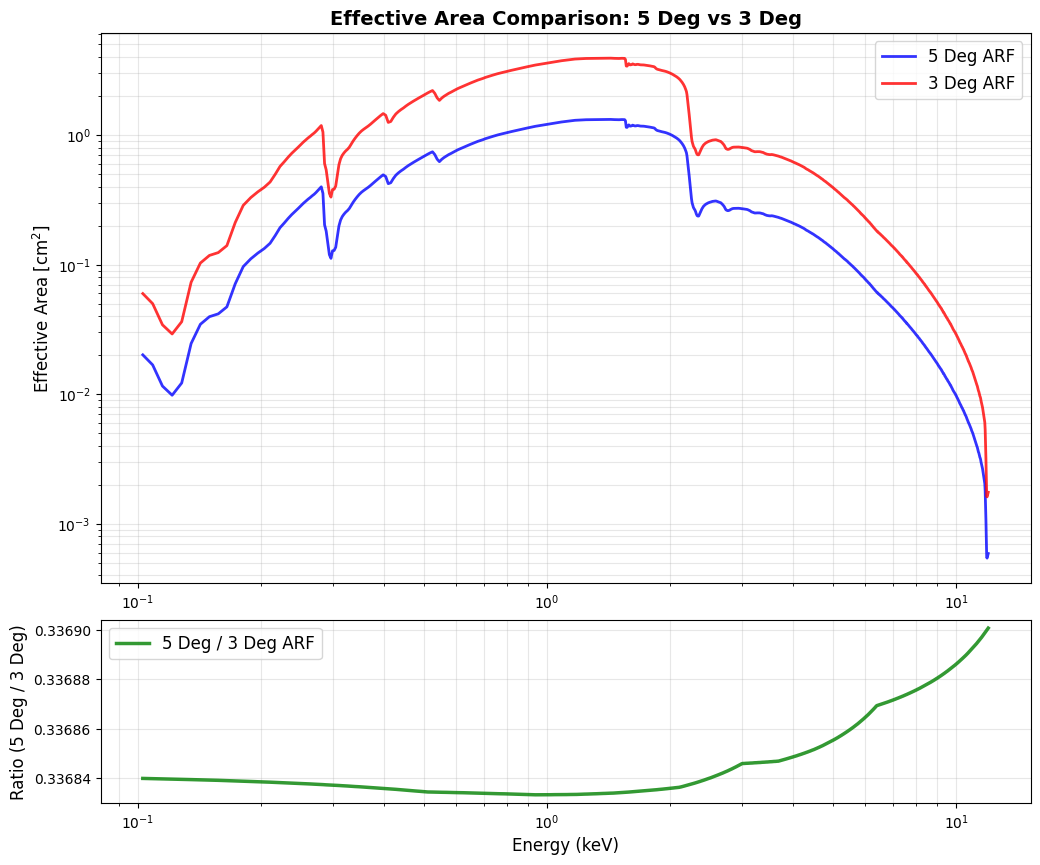


5_Deg_New: 825 energy bins
5_Deg_OLD: 825 energy bins
5_Deg_New energy range: 0.305 - 8.983 keV
5_Deg_OLD energy range: 0.305 - 8.983 keV

Statistics:
5_Deg_New - Total counts: 1.2
5_Deg_OLD - Total counts: 1.8
Mean ratio (where defined): 0.824 ± 0.145


/tmp/ipykernel_57950/1260269547.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


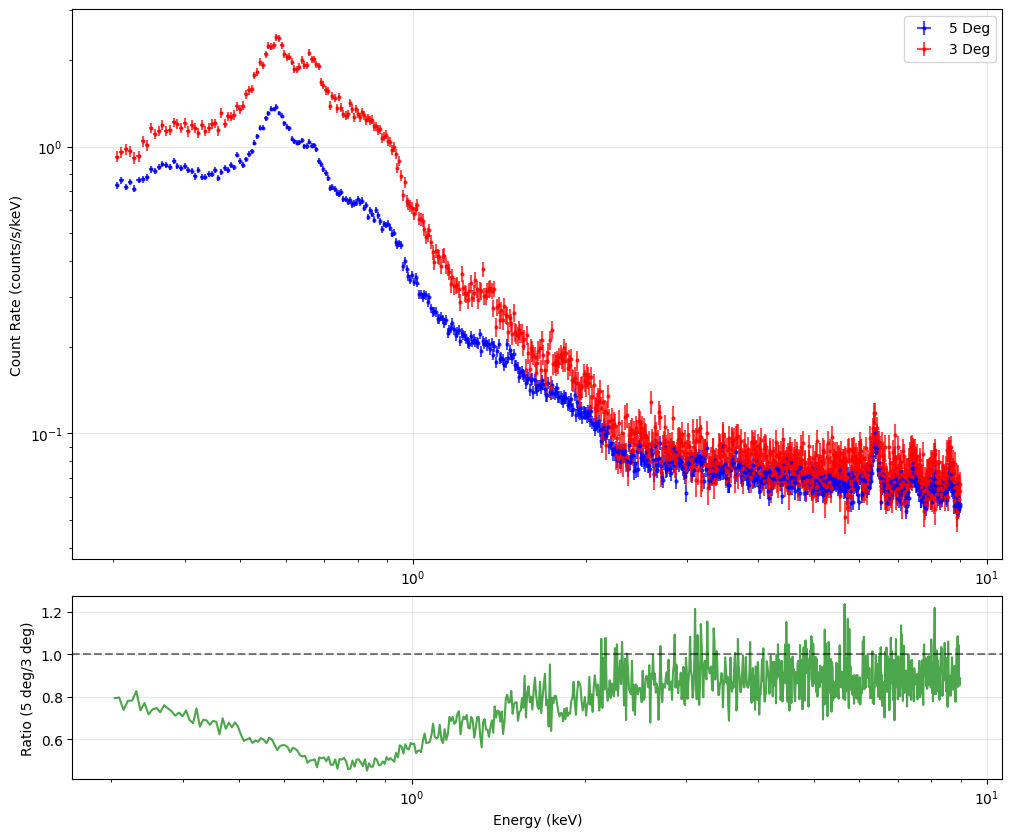

In [8]:
# Clear current data and reload both datasets
AllData.clear()

# Load 5Deg_New data
path_5Deg_New = "/home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80_DECEMBER/"
filespectrumTM1_5Deg_New = path_5Deg_New + "srctoolout_720_SourceSpec_00001.fits"
fileRMFTM1_5Deg_New = path_5Deg_New + "srctoolout_720_RMF_00001.fits"
fileARFTM1_5Deg_New = path_5Deg_New + "srctoolout_720_ARF_00001.fits"

# Load 3Deg data
path_3Deg = "/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
# "/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
filespectrumTM1_3Deg = path_3Deg + "srctoolout_720_SourceSpec_00001.fits"
fileRMFTM1_3Deg = path_3Deg + "srctoolout_720_RMF_00001.fits"
fileARFTM1_3Deg = path_3Deg + "srctoolout_720_ARF_00001.fits"

vfileARF = [fileARFTM1_5Deg_New, fileARFTM1_3Deg]
# Load both spectra into XSPEC
Spectrum(filespectrumTM1_5Deg_New)  # This becomes group 1
AllData(1).multiresponse[0] = fileRMFTM1_5Deg_New
AllData(1).multiresponse[0].arf = fileARFTM1_5Deg_New
AllData(1).multiresponse[1] = fileRMFTM1_5Deg_New

Spectrum(filespectrumTM1_3Deg)  # This becomes group 2
AllData(2).multiresponse[0] = fileRMFTM1_3Deg
AllData(2).multiresponse[0].arf = fileARFTM1_3Deg
AllData(2).multiresponse[1] = fileRMFTM1_3Deg

AllData.show()

# Set energy range
Eallmin = 0.3
Eallmax = 9.
str_range = "**-"+str(round(Eallmin, 4))+",,"+str(round(Eallmax, 4))+"-**"
print(f"Energy range: {str_range}")
AllData.ignore(str_range)

# Plot both datasets
Plot.commands = ()
Plot.addCommand("area")
Plot.xAxis = "keV"
Plot("data")

# Extract data for both groups
def extract_plot_data(group_num):
    """Extract plotting data for a specific group"""
    energies = np.asarray(Plot.x(group_num))
    edeltas = np.asarray(Plot.xErr(group_num))
    rates = np.asarray(Plot.y(group_num))
    errors = np.asarray(Plot.yErr(group_num))
    return energies, edeltas, rates, errors

# Get data for both groups
energies_5Deg_New, edeltas_5Deg_New, rates_5Deg_New, errors_5Deg_New = extract_plot_data(1)
energies_3Deg, edeltas_3Deg, rates_3Deg, errors_3Deg = extract_plot_data(2)


arf5deg = fits.open(fileARFTM1_5Deg_New)['SPECRESP']
arf5degELOW = arf5deg.data.field('ENERG_LO')#keV
arf5degEHI = arf5deg.data.field('ENERG_HI')#keV
arf5degAeff = arf5deg.data.field('SPECRESP')#cm2
arf5degE = (arf5degELOW + arf5degEHI)/2.

arf3deg = fits.open(fileARFTM1_3Deg)['SPECRESP']
arf3degELOW = arf3deg.data.field('ENERG_LO')#keV
arf3degEHI = arf3deg.data.field('ENERG_HI')#keV
arf3degAeff = arf3deg.data.field('SPECRESP')#cm2
arf3degE = (arf3degELOW + arf3degEHI)/2.

# ============================================================================
# ARF RATIO COMPARISON
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10),
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# Top panel: Both ARF curves
ax1.plot(arf5degE, arf5degAeff, label='5 Deg ARF', color='blue', linewidth=2, alpha=0.8)
ax1.plot(arf3degE, arf3degAeff, label='3 Deg ARF', color='red', linewidth=2, alpha=0.8)

ax1.set_ylabel(r'Effective Area [cm$^2$]', fontsize=12)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=12)
ax1.set_title('Effective Area Comparison: 5 Deg vs 3 Deg', fontsize=14, weight='bold')

# Bottom panel: ARF ratio
from scipy.interpolate import interp1d

# Create masks for valid ARF data
mask_arf_3deg = arf3degAeff > 0
mask_arf_5deg = arf5degAeff > 0

if np.sum(mask_arf_3deg) > 1 and np.sum(mask_arf_5deg) > 1:
    # Interpolate 3deg ARF to 5deg energy grid
    interp_arf_func = interp1d(arf3degE[mask_arf_3deg], arf3degAeff[mask_arf_3deg],
                              kind='linear', bounds_error=False, fill_value=np.nan)
    arf_3deg_interp = interp_arf_func(arf5degE)
    
    # Calculate ARF ratio
    arf_ratio_mask = mask_arf_5deg & np.isfinite(arf_3deg_interp) & (arf_3deg_interp > 0)
    arf_ratio = np.full_like(arf5degE, np.nan)
    arf_ratio[arf_ratio_mask] = arf5degAeff[arf_ratio_mask] / arf_3deg_interp[arf_ratio_mask]
    print("\n" + "="*60)
    print(f"Number of valid ARF ratio points: {np.sum(arf_ratio_mask)}")
    # Plot ARF ratio
    valid_arf_ratio = np.isfinite(arf_ratio)
    print(f"Number of valid ARF ratio points for plotting: {np.sum(valid_arf_ratio)}")
    print(f"ARF ratio values (first 10): {arf_ratio[valid_arf_ratio][:10]}")
    ax2.plot(arf5degE[valid_arf_ratio], arf_ratio[valid_arf_ratio],
            color='green', linewidth=2.5, alpha=0.8, label='5 Deg / 3 Deg ARF')
    
    # ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Print ARF ratio statistics
    print("\n" + "="*60)
    print("ARF RATIO STATISTICS")
    print("="*60)
    print(f"Mean ARF ratio (5 deg / 3 deg): {np.nanmean(arf_ratio):.4f}")
    print(f"Std Dev ARF ratio: {np.nanstd(arf_ratio):.4f}")
    print(f"Min ARF ratio: {np.nanmin(arf_ratio):.4f} at E = {arf5degE[np.nanargmin(arf_ratio)]:.3f} keV")
    print(f"Max ARF ratio: {np.nanmax(arf_ratio):.4f} at E = {arf5degE[np.nanargmax(arf_ratio)]:.3f} keV")
    
else:
    print("\n" + "="*60)
    print("Not enough valid ARF data points for ratio calculation")

ax2.set_xlabel('Energy (keV)', fontsize=12)
ax2.set_ylabel('Ratio (5 Deg / 3 Deg)', fontsize=12)
ax2.set_xscale("log")
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=12)
# ax2.set_ylim(0.95, 1.35) # Adjust range to focus on ratio deviations

plt.tight_layout()
plt.show()

print(f"\n5_Deg_New: {len(energies_5Deg_New)} energy bins")
print(f"5_Deg_OLD: {len(energies_3Deg)} energy bins")
print(f"5_Deg_New energy range: {np.min(energies_5Deg_New):.3f} - {np.max(energies_5Deg_New):.3f} keV")
print(f"5_Deg_OLD energy range: {np.min(energies_3Deg):.3f} - {np.max(energies_3Deg):.3f} keV")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# Top panel: Both spectra
ax1.errorbar(energies_5Deg_New, rates_5Deg_New, xerr=edeltas_5Deg_New, yerr=errors_5Deg_New,
             fmt='.', markersize=4, label='5 Deg', color='blue', alpha=0.7)
ax1.errorbar(energies_3Deg, rates_3Deg, xerr=edeltas_3Deg, yerr=errors_3Deg,
             fmt='.', markersize=4, label='3 Deg', color='red', alpha=0.7)

ax1.set_ylabel('Count Rate (counts/s/keV)')
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)
ax1.legend()
# ax1.set_title('Comparison of 3 deg Rebin 80 vs 5 deg Rebin 80')

# Bottom panel: Ratio
# Interpolate 3Deg data to 5Deg_New energy grid for ratio calculation
from scipy.interpolate import interp1d

# Create interpolation function for 3Deg data
# Use only finite values for interpolation
mask_3Deg = np.isfinite(rates_3Deg) & (rates_3Deg > 0)
mask_5Deg_New = np.isfinite(rates_5Deg_New) & (rates_5Deg_New > 0)

if np.sum(mask_3Deg) > 1 and np.sum(mask_5Deg_New) > 1:
    # Interpolate 3Deg rates to 5Deg_New energy grid
    interp_func = interp1d(energies_3Deg[mask_3Deg], rates_3Deg[mask_3Deg], 
                          kind='linear', bounds_error=False, fill_value=np.nan)
    rates_3Deg_interp = interp_func(energies_5Deg_New)
    
    # Calculate ratio where both datasets have valid data
    ratio_mask = mask_5Deg_New & np.isfinite(rates_3Deg_interp) & (rates_3Deg_interp > 0)
    ratio = np.full_like(energies_5Deg_New, np.nan)
    ratio[ratio_mask] = rates_5Deg_New[ratio_mask] / rates_3Deg_interp[ratio_mask]
    
    # Calculate ratio errors (approximate)
    ratio_errors = np.full_like(energies_5Deg_New, np.nan)
    ratio_errors[ratio_mask] = ratio[ratio_mask] * np.sqrt(
        (errors_5Deg_New[ratio_mask] / rates_5Deg_New[ratio_mask])**2 +
        (interp1d(energies_3Deg[mask_3Deg], errors_3Deg[mask_3Deg], 
                 kind='linear', bounds_error=False, fill_value=np.nan)(energies_5Deg_New[ratio_mask]) / 
         rates_3Deg_interp[ratio_mask])**2
    )
    
    # Plot ratio
    valid_ratio = np.isfinite(ratio) & np.isfinite(ratio_errors)
    # ax2.errorbar(energies_5Deg_New[valid_ratio], ratio[valid_ratio], 
    #             xerr=edeltas_5Deg_New[valid_ratio], yerr=ratio_errors[valid_ratio],
    #             fmt='.', markersize=4, color='green', alpha=0.7)
    ax2.plot(energies_5Deg_New[valid_ratio], ratio[valid_ratio], 
                               markersize=4, color='green', alpha=0.7)
    ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
else:
    print("Not enough valid data points for ratio calculation")

ax2.set_xlabel('Energy (keV)')
ax2.set_ylabel('Ratio (5 deg/3 deg)')
ax2.set_xscale("log")
ax2.grid(True, alpha=0.3)
# ax2.set_ylim(0.5, 2.0)  # Adjust as needed

plt.tight_layout()

# Print statistics
print("\nStatistics:")
print(f"5_Deg_New - Total counts: {np.sum(rates_5Deg_New * edeltas_5Deg_New * 2):.1f}")
print(f"5_Deg_OLD - Total counts: {np.sum(rates_3Deg * edeltas_3Deg * 2):.1f}")
print(f"Mean ratio (where defined): {np.nanmean(ratio):.3f} ± {np.nanstd(ratio):.3f}")

# # Create comparison plot
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
#                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# # Top panel: Both spectra
# ax1.errorbar(energies_5Deg_New, rates_5Deg_New/arf5degAeff, xerr=edeltas_5Deg_New, yerr=errors_5Deg_New,
#              fmt='.', markersize=4, label='5 deg Rebin 80', color='blue', alpha=0.7)
# ax1.errorbar(energies_3Deg, rates_3Deg/arf3degAeff, xerr=edeltas_3Deg, yerr=errors_3Deg,
#              fmt='.', markersize=4, label='3 deg Rebin 80', color='red', alpha=0.7)

# ax1.set_ylabel('Count Rate (counts/s/keV)')
# ax1.set_xscale("log")
# ax1.set_yscale("log")
# ax1.grid(True, alpha=0.3)
# ax1.legend()
# ax1.set_title('Comparison of 3 deg Rebin 80 vs 5 deg Rebin 80')


In [4]:

print('ARF energy array length 5 deg:', len(arf5degE))
print('ARF energy array length 3 deg:', len(arf3degE))
print('Rate energy array length 5 deg:', len(energies_5Deg_New))
print('Rate energy array length 3 deg:', len(energies_3Deg))

print('ARF 5 deg energy range: {:.3f} - {:.3f} keV'.format(np.min(arf5degE), np.max(arf5degE)))
print('ARF 3 deg energy range: {:.3f} - {:.3f} keV'.format(np.min(arf3degE), np.max(arf3degE))) 
print('Rate 5 deg energy range: {:.3f} - {:.3f} keV'.format(np.min(energies_5Deg_New), np.max(energies_5Deg_New)))
print('Rate 3 deg energy range: {:.3f} - {:.3f} keV'.format(np.min(energies_3Deg), np.max(energies_3Deg)))

print(arf5degE[0:20])
print(arf3degE[0:20])
print(energies_5Deg_New[0:20])
print(energies_3Deg[0:20])

ARF energy array length 5 deg: 1024
ARF energy array length 3 deg: 1024
Rate energy array length 5 deg: 825
Rate energy array length 3 deg: 825
ARF 5 deg energy range: 0.103 - 11.987 keV
ARF 3 deg energy range: 0.103 - 11.987 keV
Rate 5 deg energy range: 0.305 - 8.983 keV
Rate 3 deg energy range: 0.305 - 8.983 keV
[0.1028685  0.10874628 0.1149056  0.1213414  0.12804756 0.13501488
 0.14222789 0.14966816 0.1573103  0.1651215  0.17306086 0.18104449
 0.18890913 0.19652592 0.20378369 0.21055664 0.21682702 0.22264478
 0.22805771 0.23310682]
[0.1028685  0.10874628 0.1149056  0.1213414  0.12804756 0.13501488
 0.14222789 0.14966816 0.1573103  0.1651215  0.17306086 0.18104449
 0.18890913 0.19652592 0.20378369 0.21055664 0.21682702 0.22264478
 0.22805771 0.23310682]
[0.30455071 0.31001943 0.31550269 0.32100053 0.32651295 0.33203994
 0.33758155 0.34313774 0.34870857 0.35429406 0.3598942  0.365509
 0.37113848 0.37678264 0.38244152 0.38811514 0.39380346 0.39950651
 0.40522432 0.4109569 ]
[0.30455071

CALCULATING AREAS FROM CHEESEMASKS
Processing cheesemask: /home/jortecal/GitHub/eRosita/LMC5DegEv/cheesemask_comb_LMC_rad5deg_rebin80.fits
Cheesemask shape: (9024, 9078)
Data type: uint8
Min/Max values: 0.000 / 1.000
Valid pixels: 39507506 / 81919872 (48.2%)
Pixel scale from CDELT1: 0.001111 deg/pixel
Pixel area: 1.23e-06 deg²/pixel
Total valid area: 48.775 deg² = 1.49e-02 sr

----------------------------------------
Processing cheesemask: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/cheesemask_LMC_Circle_masked_Bckg_masked.fits
Cheesemask shape: (10876, 10888)
Data type: uint8
Min/Max values: 0.000 / 1.000
Valid pixels: 55607773 / 118417888 (47.0%)
Pixel scale from CDELT1: 0.000556 deg/pixel
Pixel area: 3.09e-07 deg²/pixel
Total valid area: 17.163 deg² = 5.23e-03 sr

AREA COMPARISON
Bin40 area: 48.7747 deg² = 1.4858e-02 sr
Bin80 area: 17.1629 deg² = 5.2281e-03 sr
Area ratio (40/80): 2.841869

SURFACE BRIGHTNESS ANALYSIS
Mean surface brightness ratio (40/80): 0.2898 ± 0.0512

SURFACE 

/tmp/ipykernel_57950/2550659338.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


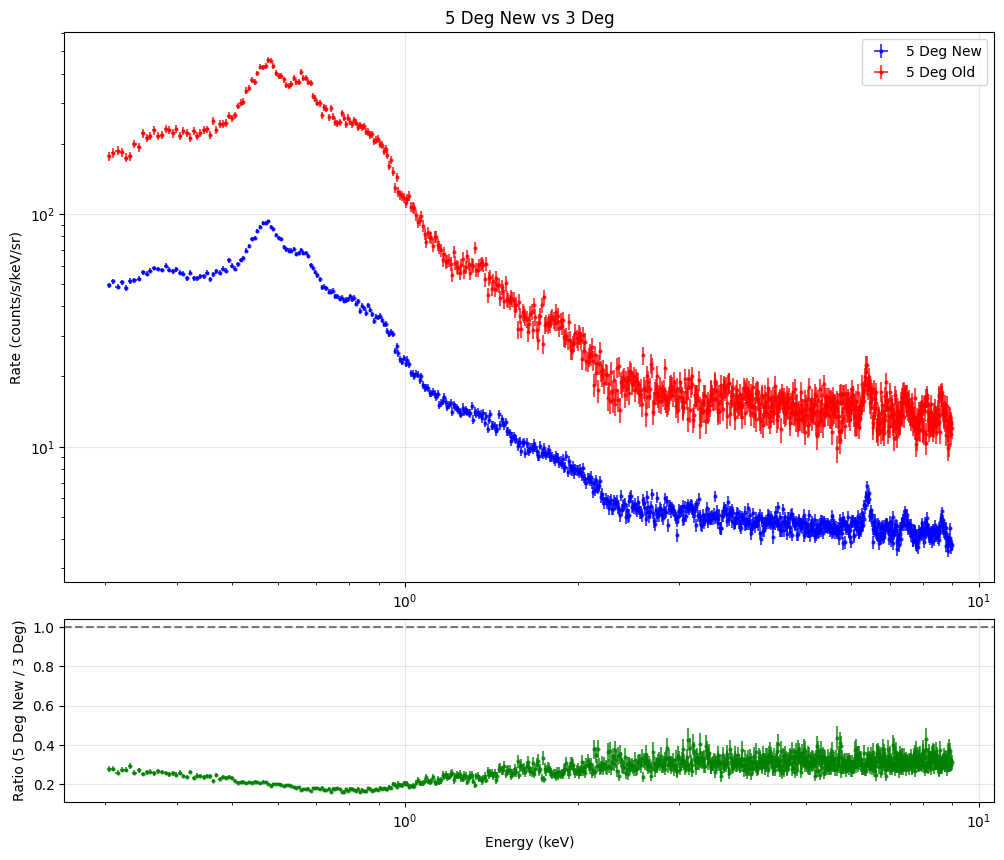

In [9]:
def calculate_area_from_fits_cheesemask(fits_file):
    """Calculate area from FITS cheesemask file"""
    from astropy.io import fits
    from astropy.wcs import WCS
    import numpy as np
    
    print(f"Processing cheesemask: {fits_file}")
    
    with fits.open(fits_file) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        
        print(f"Cheesemask shape: {data.shape}")
        print(f"Data type: {data.dtype}")
        print(f"Min/Max values: {np.min(data):.3f} / {np.max(data):.3f}")
        
        # Count valid pixels (assuming mask=1 means valid, mask=0 means masked out)
        valid_pixels = np.sum(data > 0)
        total_pixels = data.size
        
        print(f"Valid pixels: {valid_pixels} / {total_pixels} ({100*valid_pixels/total_pixels:.1f}%)")
        
        # Get pixel scale from header
        try:
            # Try different header keywords for pixel scale
            if 'CDELT1' in header:
                pixscale_deg = abs(header['CDELT1'])  # degrees per pixel
                print(f"Pixel scale from CDELT1: {pixscale_deg:.6f} deg/pixel")
            elif 'CD1_1' in header:
                pixscale_deg = abs(header['CD1_1'])  # degrees per pixel  
                print(f"Pixel scale from CD1_1: {pixscale_deg:.6f} deg/pixel")
            else:
                # Try to get from WCS
                wcs = WCS(header)
                pixscale_deg = abs(wcs.wcs.cdelt[0])  # assuming square pixels
                print(f"Pixel scale from WCS: {pixscale_deg:.6f} deg/pixel")
                
        except Exception as e:
            print(f"Error determining pixel scale: {e}")
            print("Available header keywords related to scale:")
            scale_keys = [k for k in header.keys() if any(x in k.upper() for x in ['CDELT', 'CD1', 'CD2', 'SCALE', 'PIX'])]
            for key in scale_keys:
                print(f"  {key}: {header[key]}")
            return None, None
        
        # Calculate areas
        pixel_area_deg2 = pixscale_deg**2
        total_area_deg2 = valid_pixels * pixel_area_deg2
        
        # Convert to steradians
        deg2_to_sr = (np.pi/180)**2
        area_sr = total_area_deg2 * deg2_to_sr
        
        print(f"Pixel area: {pixel_area_deg2:.2e} deg²/pixel")
        print(f"Total valid area: {total_area_deg2:.3f} deg² = {area_sr:.2e} sr")
        
        return area_sr, total_area_deg2

# Define paths to cheesemask files
cheesemask_5Deg_energies_5Deg_New = "/home/jortecal/GitHub/eRosita/LMC5DegEv/cheesemask_comb_LMC_rad5deg_rebin80.fits"
cheesemask_3Deg = "/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/cheesemask_LMC_Circle_masked_Bckg_masked.fits"

# Calculate areas from cheesemasks
print("="*60)
print("CALCULATING AREAS FROM CHEESEMASKS")
print("="*60)

area_5Deg_New_sr, area_5Deg_New_deg2 = calculate_area_from_fits_cheesemask(cheesemask_5Deg_energies_5Deg_New)
print("\n" + "-"*40)
area_3Deg_sr, area_3Deg_deg2 = calculate_area_from_fits_cheesemask(cheesemask_3Deg)

if area_5Deg_New_sr is not None and area_3Deg_sr is not None:
    print("\n" + "="*60)
    print("AREA COMPARISON")
    print("="*60)
    print(f"Bin40 area: {area_5Deg_New_deg2:.4f} deg² = {area_5Deg_New_sr:.4e} sr")
    print(f"Bin80 area: {area_3Deg_deg2:.4f} deg² = {area_3Deg_sr:.4e} sr")
    print(f"Area ratio (40/80): {area_5Deg_New_sr/area_3Deg_sr:.6f}")
    
    # Convert count rates to surface brightness
    surf_bright_5Deg_energies_5Deg_New = rates_5Deg_New / area_5Deg_New_sr  # counts/s/keV/sr
    surf_bright_3Deg = rates_3Deg / area_3Deg_sr
    
    surf_bright_errors_5Deg_energies_5Deg_New = errors_5Deg_New / area_5Deg_New_sr
    surf_bright_errors_3Deg = errors_3Deg / area_3Deg_sr
    
    print("\n" + "="*60)
    print("SURFACE BRIGHTNESS ANALYSIS")
    print("="*60)
    
    # Create surface brightness comparison plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

    # Top panel: Surface brightness comparison
    ax1.errorbar(energies_5Deg_New, surf_bright_5Deg_energies_5Deg_New, xerr=edeltas_5Deg_New, yerr=surf_bright_errors_5Deg_energies_5Deg_New,
                 fmt='.', markersize=4, label='5 Deg New', color='blue', alpha=0.7)
    ax1.errorbar(energies_3Deg, surf_bright_3Deg, xerr=edeltas_3Deg, yerr=surf_bright_errors_3Deg,
                 fmt='.', markersize=4, label='5 Deg Old', color='red', alpha=0.7)

    ax1.set_ylabel('Rate (counts/s/keV/sr)')
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_title('5 Deg New vs 3 Deg')

    # Bottom panel: Surface brightness ratio
    # Use the same interpolation approach as before
    mask_3Deg = np.isfinite(surf_bright_3Deg) & (surf_bright_3Deg > 0)
    mask_5Deg_energies_5Deg_New = np.isfinite(surf_bright_5Deg_energies_5Deg_New) & (surf_bright_5Deg_energies_5Deg_New > 0)
    
    if np.sum(mask_3Deg) > 1 and np.sum(mask_5Deg_energies_5Deg_New) > 1:
        # Interpolate 3Deg surface brightness to 5Deg_energies_5Deg_New energy grid
        from scipy.interpolate import interp1d
        interp_func = interp1d(energies_3Deg[mask_3Deg], surf_bright_3Deg[mask_3Deg], 
                              kind='linear', bounds_error=False, fill_value=np.nan)
        surf_bright_3Deg_interp = interp_func(energies_5Deg_New)
        
        # Calculate surface brightness ratio
        ratio_mask = mask_5Deg_energies_5Deg_New & np.isfinite(surf_bright_3Deg_interp) & (surf_bright_3Deg_interp > 0)
        surf_ratio = np.full_like(energies_5Deg_New, np.nan)
        surf_ratio[ratio_mask] = surf_bright_5Deg_energies_5Deg_New[ratio_mask] / surf_bright_3Deg_interp[ratio_mask]
        
        # Calculate ratio errors
        surf_ratio_errors = np.full_like(energies_5Deg_New, np.nan)
        surf_bright_errors_3Deg_interp = interp1d(energies_3Deg[mask_3Deg], surf_bright_errors_3Deg[mask_3Deg], 
                                                  kind='linear', bounds_error=False, fill_value=np.nan)(energies_5Deg_New[ratio_mask])
        
        surf_ratio_errors[ratio_mask] = surf_ratio[ratio_mask] * np.sqrt(
            (surf_bright_errors_5Deg_energies_5Deg_New[ratio_mask] / surf_bright_5Deg_energies_5Deg_New[ratio_mask])**2 +
            (surf_bright_errors_3Deg_interp / surf_bright_3Deg_interp[ratio_mask])**2
        )
        
        # Plot surface brightness ratio
        valid_ratio = np.isfinite(surf_ratio) & np.isfinite(surf_ratio_errors)
        ax2.errorbar(energies_5Deg_New[valid_ratio], surf_ratio[valid_ratio], 
                    xerr=edeltas_5Deg_New[valid_ratio], yerr=surf_ratio_errors[valid_ratio],
                    fmt='.', markersize=4, color='green', alpha=0.7)
        ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
        
        # Print ratio statistics
        print(f"Mean surface brightness ratio (40/80): {np.nanmean(surf_ratio):.4f} ± {np.nanstd(surf_ratio):.4f}")

    ax2.set_xlabel('Energy (keV)')
    ax2.set_ylabel('Ratio (5 Deg New / 3 Deg)')
    ax2.set_xscale("log")
    ax2.grid(True, alpha=0.3)
    # ax2.set_ylim(0.6, 1.4)  # Tighter range for surface brightness ratio

    plt.tight_layout()
    
    # Print comprehensive statistics
    print("\nSURFACE BRIGHTNESS STATISTICS:")
    print(f"Bin40 - Mean Rate: {np.mean(surf_bright_5Deg_energies_5Deg_New[np.isfinite(surf_bright_5Deg_energies_5Deg_New)]):.2e} counts/s/keV/sr")
    print(f"Bin80 - Mean Rate: {np.mean(surf_bright_3Deg[np.isfinite(surf_bright_3Deg)]):.2e} counts/s/keV/sr")
    print(f"Bin40 - Total flux: {np.sum(rates_5Deg_New * edeltas_5Deg_New * 2):.1f} counts/s")
    print(f"Bin80 - Total flux: {np.sum(rates_3Deg * edeltas_3Deg * 2):.1f} counts/s")
    print(f"Bin40 - Total Rate flux: {np.sum(surf_bright_5Deg_energies_5Deg_New * edeltas_5Deg_New * 2):.2e} counts/s/sr")
    print(f"Bin80 - Total Rate flux: {np.sum(surf_bright_3Deg * edeltas_3Deg * 2):.2e} counts/s/sr")

else:
    print("Could not calculate areas from cheesemask files.")
    print("Please check file paths and header information.")

ARF 5 Deg New: 1024 energy bins
ARF 3 Deg: 1024 energy bins
Effective area range 5 Deg New: 0.0 - 1.3 cm²
Effective area range 3 Deg: 0.0 - 3.9 cm²

FLUX STATISTICS:
5 Deg New - Total flux: 5.70e+02 counts/s/cm²
3 Deg - Total flux: 6.44e+02 counts/s/cm²
Mean flux ratio (where defined): 0.860 ± 0.152


/tmp/ipykernel_57950/2813514139.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


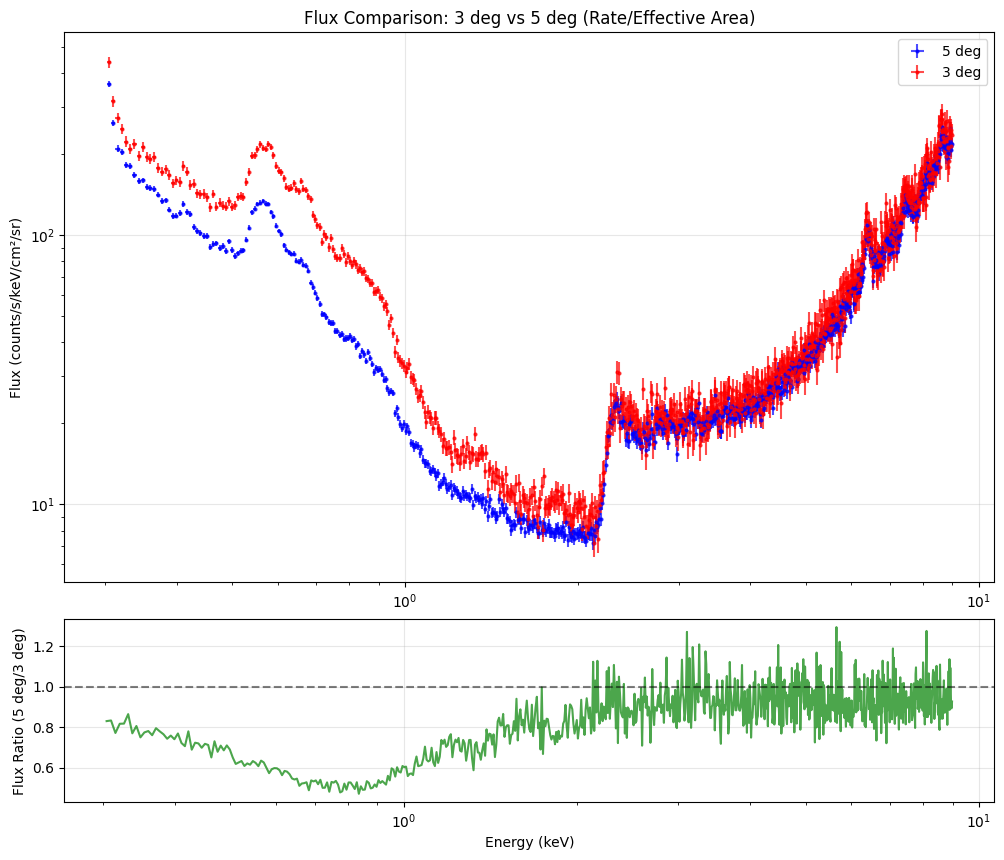

In [ ]:
# Get effective areas from ARF files
def get_effective_area(arf_file):
    """Extract effective area from ARF file"""
    with fits.open(arf_file) as hdul:
        # ARF files typically have SPECRESP extension
        if 'SPECRESP' in [hdul[i].name for i in range(len(hdul))]:
            arf_data = hdul['SPECRESP'].data
        else:
            arf_data = hdul[1].data  # fallback to first extension
        
        energ_lo = arf_data['ENERG_LO']
        energ_hi = arf_data['ENERG_HI']
        specresp = arf_data['SPECRESP']  # effective area in cm²
        
        # Calculate energy midpoints
        energy_mid = (energ_lo + energ_hi) / 2.0
        
        return energy_mid, specresp

# Extract effective areas
energy_arf_5Deg_New, eff_area_5Deg_New = get_effective_area(fileARFTM1_5Deg_New)
energy_arf_3Deg, eff_area_3Deg = get_effective_area(fileARFTM1_3Deg)

print(f"ARF 5 Deg New: {len(energy_arf_5Deg_New)} energy bins")
print(f"ARF 3 Deg: {len(energy_arf_3Deg)} energy bins")
print(f"Effective area range 5 Deg New: {np.min(eff_area_5Deg_New):.1f} - {np.max(eff_area_5Deg_New):.1f} cm²")
print(f"Effective area range 3 Deg: {np.min(eff_area_3Deg):.1f} - {np.max(eff_area_3Deg):.1f} cm²")

# Interpolate effective areas to match spectral energy grids
from scipy.interpolate import interp1d

# Interpolate ARF effective areas to spectral energy grids  
interp_eff_area_5Deg_New = interp1d(energy_arf_5Deg_New, eff_area_5Deg_New, 
                                 kind='linear', bounds_error=False, fill_value=0)(energies_5Deg_New)
interp_eff_area_3Deg = interp1d(energy_arf_3Deg, eff_area_3Deg,
                                 kind='linear', bounds_error=False, fill_value=0)(energies_3Deg)

# Convert rates to flux by dividing by effective area
# Rate [counts/s/keV] / Effective Area [cm²] = Flux [counts/s/keV/cm²]
flux_5Deg_New = np.where(interp_eff_area_5Deg_New > 0, rates_5Deg_New / interp_eff_area_5Deg_New, np.nan)
flux_3Deg = np.where(interp_eff_area_3Deg > 0, rates_3Deg / interp_eff_area_3Deg, np.nan)

flux_errors_5Deg_New = np.where(interp_eff_area_5Deg_New > 0, errors_5Deg_New / interp_eff_area_5Deg_New, np.nan)
flux_errors_3Deg = np.where(interp_eff_area_3Deg > 0, errors_3Deg / interp_eff_area_3Deg, np.nan)

# Create flux comparison plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})
flux_5Deg_New /= area_5Deg_New_sr
flux_3Deg /= area_3Deg_sr
flux_errors_5Deg_New /= area_5Deg_New_sr
flux_errors_3Deg /= area_3Deg_sr
# Top panel: Both flux spectra
ax1.errorbar(energies_5Deg_New, flux_5Deg_New, xerr=edeltas_5Deg_New, yerr=flux_errors_5Deg_New,
             fmt='.', markersize=4, label='5 deg', color='blue', alpha=0.7)
ax1.errorbar(energies_3Deg, flux_3Deg, xerr=edeltas_3Deg, yerr=flux_errors_3Deg,
             fmt='.', markersize=4, label='3 deg', color='red', alpha=0.7)

ax1.set_ylabel('Flux (counts/s/keV/cm²/sr)')
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Flux Comparison: 3 deg vs 5 deg (Rate/Effective Area)')

# Bottom panel: Flux ratio
# Create masks for valid flux data
mask_flux_3Deg = np.isfinite(flux_3Deg) & (flux_3Deg > 0)
mask_flux_5Deg_New = np.isfinite(flux_5Deg_New) & (flux_5Deg_New > 0)
Sí, parece 
if np.sum(mask_flux_3Deg) > 1 and np.sum(mask_flux_5Deg_New) > 1:
    # Interpolate 3Deg flux to 5Deg_New energy grid
    interp_flux_func = interp1d(energies_3Deg[mask_flux_3Deg], flux_3Deg[mask_flux_3Deg], 
                               kind='linear', bounds_error=False, fill_value=np.nan)
    flux_3Deg_interp = interp_flux_func(energies_5Deg_New)
    
    # Calculate flux ratio
    flux_ratio_mask = mask_flux_5Deg_New & np.isfinite(flux_3Deg_interp) & (flux_3Deg_interp > 0)
    flux_ratio = np.full_like(energies_5Deg_New, np.nan)
    flux_ratio[flux_ratio_mask] = flux_5Deg_New[flux_ratio_mask] / flux_3Deg_interp[flux_ratio_mask]
    
    # Calculate flux ratio errors
    flux_ratio_errors = np.full_like(energies_5Deg_New, np.nan)
    flux_errors_3Deg_interp = interp1d(energies_3Deg[mask_flux_3Deg], flux_errors_3Deg[mask_flux_3Deg], 
                                       kind='linear', bounds_error=False, fill_value=np.nan)(energies_5Deg_New[flux_ratio_mask])
    
    flux_ratio_errors[flux_ratio_mask] = flux_ratio[flux_ratio_mask] * np.sqrt(
        (flux_errors_5Deg_New[flux_ratio_mask] / flux_5Deg_New[flux_ratio_mask])**2 +
        (flux_errors_3Deg_interp / flux_3Deg_interp[flux_ratio_mask])**2
    )
    
    # Plot flux ratio
    valid_flux_ratio = np.isfinite(flux_ratio) & np.isfinite(flux_ratio_errors)
    # ax2.errorbar(energies_5Deg_New[valid_flux_ratio], flux_ratio[valid_flux_ratio], 
    #             xerr=edeltas_5Deg_New[valid_flux_ratio], yerr=flux_ratio_errors[valid_flux_ratio],
    #             fmt='.', markersize=4, color='green', alpha=0.7)
    ax2.plot(energies_5Deg_New[valid_flux_ratio], flux_ratio[valid_flux_ratio], markersize=4, color='green', alpha=0.7)
    ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
else:
    print("Not enough valid data points for flux ratio calculation")

ax2.set_xlabel('Energy (keV)')
ax2.set_ylabel('Flux Ratio (5 deg/3 deg)')
ax2.set_xscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Print flux statistics
print("\nFLUX STATISTICS:")
print(f"5 Deg New - Total flux: {np.nansum(flux_5Deg_New * edeltas_5Deg_New * 2):.2e} counts/s/cm²")
print(f"3 Deg - Total flux: {np.nansum(flux_3Deg * edeltas_3Deg * 2):.2e} counts/s/cm²")
print(f"Mean flux ratio (where defined): {np.nanmean(flux_ratio):.3f} ± {np.nanstd(flux_ratio):.3f}")